In [ ]:
# ---------------------------------------------
# IMPORTS
# ---------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


c:\Users\hpCND\Anaconda3\envs\tf\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [ ]:
# ---------------------------------------------
# LOAD CIFAR-10 DATASET
# ---------------------------------------------
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

# Normalize images [-1,1] for tanh
x_train = (x_train.astype('float32') - 127.5) / 127.5

latent_dim = 100
img_shape = (32, 32, 3)
batch_size = 64
epochs = 2000

In [ ]:
# ---------------------------------------------
# BUILD GENERATOR
# ---------------------------------------------
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(8*8*256, input_dim=latent_dim),
        layers.Reshape((8, 8, 256)),

        layers.Conv2DTranspose(128, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2DTranspose(64, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.Conv2D(3, 3, padding='same', activation='tanh')
    ])
    return model

In [ ]:
# ---------------------------------------------
# BUILD DISCRIMINATOR
# ---------------------------------------------
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, 3, strides=2, padding='same', input_shape=img_shape),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, 3, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
# ---------------------------------------------
# INITIALIZE MODELS
# ---------------------------------------------
generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(0.0002, 0.5),
    loss='binary_crossentropy'
)

# GAN model (discriminator frozen)
discriminator.trainable = False
z = layers.Input(shape=(latent_dim,))
img = generator(z)
valid = discriminator(img)
gan = tf.keras.Model(z, valid)
gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy')

In [ ]:

d_losses, g_losses = [], []

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    z_noise = np.random.randn(batch_size, latent_dim)
    fake_imgs = generator.predict(z_noise, verbose=0)

    real_labels = np.ones((batch_size,1)) * 0.9
    fake_labels = np.zeros((batch_size,1))

    d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    z_noise = np.random.randn(batch_size, latent_dim)
    g_loss = gan.train_on_batch(z_noise, np.ones((batch_size,1)))

    # Save losses
    d_losses.append(d_loss)
    g_losses.append(g_loss)

    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")

Epoch 0 | D Loss: 0.6863 | G Loss: 0.5806
Epoch 200 | D Loss: 0.2347 | G Loss: 0.9974
Epoch 400 | D Loss: 0.4575 | G Loss: 0.6614
Epoch 600 | D Loss: 0.3996 | G Loss: 0.4295
Epoch 800 | D Loss: 0.6507 | G Loss: 0.9481
Epoch 1000 | D Loss: 0.4619 | G Loss: 0.8441
Epoch 1200 | D Loss: 0.5958 | G Loss: 1.3665
Epoch 1400 | D Loss: 0.7163 | G Loss: 0.8072
Epoch 1600 | D Loss: 0.4828 | G Loss: 1.7540
Epoch 1800 | D Loss: 0.5555 | G Loss: 0.8823


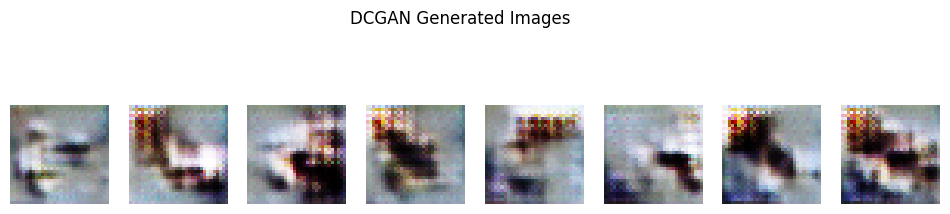

In [ ]:

num_samples = 8
plt.figure(figsize=(12,3))
for i in range(num_samples):
    z = np.random.randn(1, latent_dim)
    img = generator.predict(z, verbose=0)
    plt.subplot(1, num_samples, i+1)
    plt.imshow((img[0]+1)/2)
    plt.axis('off')
plt.suptitle("DCGAN Generated Images")
plt.show()

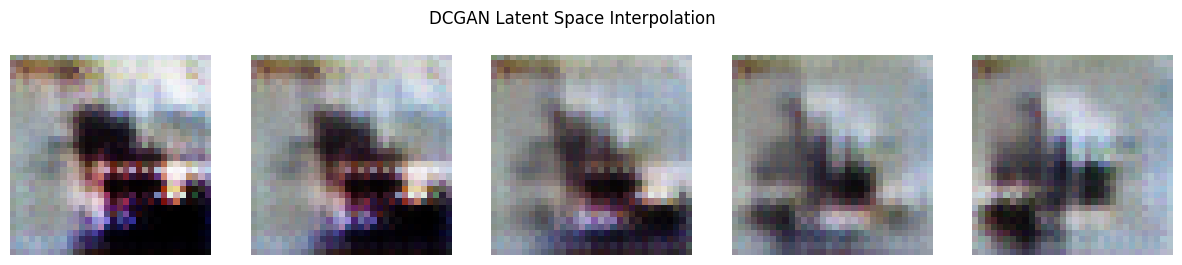

In [ ]:

def interpolate(z1, z2, steps=5):
    return [(1-a)*z1 + a*z2 for a in np.linspace(0,1,steps)]

z1 = np.random.randn(1, latent_dim)
z2 = np.random.randn(1, latent_dim)
vectors = interpolate(z1, z2, 5)

plt.figure(figsize=(15,3))
for i, z in enumerate(vectors):
    img = generator.predict(z, verbose=0)
    plt.subplot(1,5,i+1)
    plt.imshow((img[0]+1)/2)
    plt.axis('off')
plt.suptitle("DCGAN Latent Space Interpolation")
plt.show()

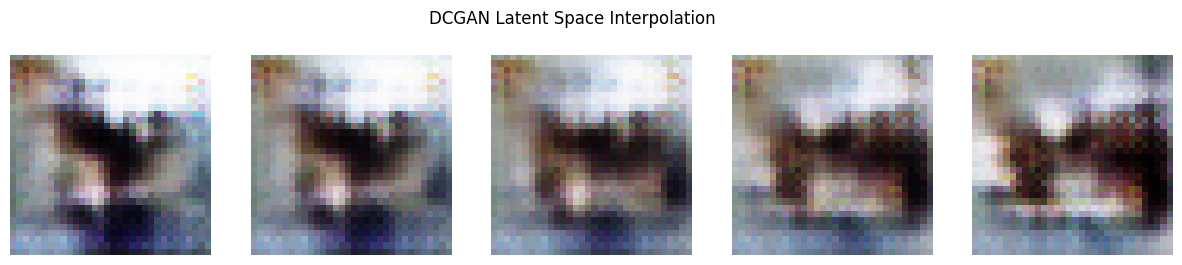

In [ ]:

def interpolate(z1, z2, steps=1):
    return [(1-a)*z1 + a*z2 for a in np.linspace(0,1,steps)]

z1 = np.random.randn(1, latent_dim)
z2 = np.random.randn(1, latent_dim)
vectors = interpolate(z1, z2, 5)

plt.figure(figsize=(15,3))
for i, z in enumerate(vectors):
    img = generator.predict(z, verbose=0)
    plt.subplot(1,5,i+1)
    plt.imshow((img[0]+1)/2)
    plt.axis('off')
plt.suptitle("DCGAN Latent Space Interpolation")
plt.show()

In [ ]:
generator.save("dcgan_generator_lab8.h5")

## Advance Gan

In [1]:

import torch 
import matplotlib.pyplot as plt
import numpy as np

model = torch.hub.load(
    'facebookresearch/pytorch_GAN_zoo:hub',
    'PGAN',
    model_name='celebAHQ-512',
    pretrained=True
)

latent_dim = model.config.latentVectorDim 

Using cache found in C:\Users\hpCND/.cache\torch\hub\facebookresearch_pytorch_GAN_zoo_hub


Average network found !


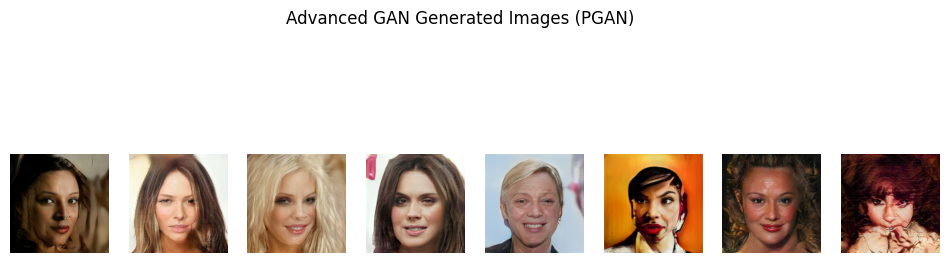

In [3]:

noise = torch.randn(8, latent_dim)
with torch.no_grad():
    images = model.test(noise)

plt.figure(figsize=(12,4))
for i in range(8):
    img = images[i].permute(1,2,0).cpu().numpy()
    img = np.clip((img + 1)/2, 0, 1)
    plt.subplot(1,8,i+1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Advanced GAN Generated Images (PGAN)")
plt.show()

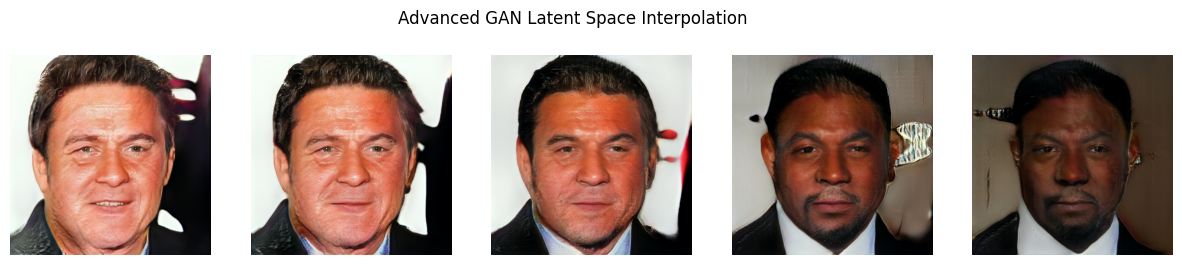

In [4]:

z1 = torch.randn(1, latent_dim)
z2 = torch.randn(1, latent_dim)
alphas = torch.linspace(0,1,5)

plt.figure(figsize=(15,3))
for i, a in enumerate(alphas):
    z = (1-a)*z1 + a*z2
    with torch.no_grad():
        img = model.test(z)[0]
    img = img.permute(1,2,0).cpu().numpy()
    img = np.clip((img+1)/2, 0, 1)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Advanced GAN Latent Space Interpolation")
plt.show()